# **7. Exploring the EC regime using the cluster-based analysis **

** This routine concerns figure 16 to 19 and table 5b from section 7 of the article "Conditional statistics of the large-scale reversal dynamics in square Rayleigh–Bénard cells" **

## Preamble

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
pd.set_option('display.max_rows',10)

params = {'backend': 'ps',
          'axes.labelsize': 16,
          'font.size': 16,
          'legend.fontsize': 16,          
          'font.size': 16,          
          'xtick.labelsize': 12,
          'ytick.labelsize': 12,
          'text.usetex': True,
          'font.family': 'serif',
          'figure.figsize': (12, 8),
          'contour.negative_linestyle':'dashed'}
plt.rcParams.update(params)

## 1. Read the time series

In [2]:
filename_modes_pr3   = './data_from_dns/modal_50000000_3_512_016to186.h5'
filename_global_pr3  = './data_from_dns/global_50000000_3_512_016to186.h5'

filename_modes_pr43   = './data_from_dns/modal_50000000_4.3_512_060to259.h5'
filename_global_pr43  = './data_from_dns/global_50000000_4.3_512_060to259.h5'

In [3]:
glb_pr3 = pd.read_hdf(filename_global_pr3)
POD_pr3 = pd.read_hdf(filename_modes_pr3)

POD_pr3['f']=POD_pr3['k1'].abs()
scale_pr3 = POD_pr3.mean()['f']

pod_pr3 = POD_pr3[['k1','k2','k3','k4','k5','k6','f']]/POD_pr3.mean()['f']
pod_pr3['t'] = glb_pr3.t
pod_pr3['CRregime'] = glb_pr3.CRregime

thres_pr3=glb_pr3.mean()['f'] + glb_pr3.std()['f']

del POD_pr3

In [4]:
glb_pr43 = pd.read_hdf(filename_global_pr43)
POD_pr43 = pd.read_hdf(filename_modes_pr43)

POD_pr43['f']=POD_pr43['k1'].abs()
scale_pr43 = POD_pr43.mean()['f']
pod_pr43 = POD_pr43[['k1','k2','k3','k4','k5','k6','f']]/POD_pr43.mean()['f']
pod_pr43['t'] = glb_pr43.t
pod_pr43['k4'] = -pod_pr43.k4
pod_pr43['CRregime'] = glb_pr43.CRregime

thres_pr43=glb_pr43.mean()['f'] + glb_pr43.std()['f']


del POD_pr43

## 2. Cluster partitioning of the 6-D subspace of modal amplitudes
### 2.1 Apply the symmetry operators

In [5]:
ec = pod_pr3.loc[pod_pr3.CRregime==False]
k1 = np.concatenate(( ec.k1.values,-ec.k1.values,-ec.k1.values, ec.k1.values))
k3 = np.concatenate(( ec.k3.values,-ec.k3.values,-ec.k3.values, ec.k3.values))
k2 = np.concatenate(( ec.k2.values, ec.k2.values, ec.k2.values, ec.k2.values))
k5 = np.concatenate(( ec.k5.values, ec.k5.values, ec.k5.values, ec.k5.values))
k4 = np.concatenate(( ec.k4.values,-ec.k4.values, ec.k4.values,-ec.k4.values))
k6 = np.concatenate(( ec.k6.values, ec.k6.values,-ec.k6.values,-ec.k6.values))

alpha_ec_pr3 = np.array([k1,k2,k3,k4,k5,k6])

In [6]:
ec2 = pod_pr43.loc[pod_pr43.CRregime==False]
k1 = np.concatenate(( ec2.k1.values,-ec2.k1.values,-ec2.k1.values, ec2.k1.values))
k3 = np.concatenate(( ec2.k4.values,-ec2.k4.values,-ec2.k4.values, ec2.k4.values))
k2 = np.concatenate(( ec2.k2.values, ec2.k2.values, ec2.k2.values, ec2.k2.values))
k5 = np.concatenate(( ec2.k5.values, ec2.k5.values, ec2.k5.values, ec2.k5.values))
k4 = np.concatenate(( ec2.k3.values,-ec2.k3.values, ec2.k3.values,-ec2.k3.values))
k6 = np.concatenate(( ec2.k6.values, ec2.k6.values,-ec2.k6.values,-ec2.k6.values))

alpha_ec_pr43 = np.array([k1,k2,k3,k4,k5,k6])

### 2.2 Partition the EC subset into $K=11$ clusters
Since this is quite expensive and the resulting clusters are not sorted. Uncomment the lines only if updating the cluster partitioning.

In [7]:
import pickle
from sklearn.cluster import KMeans

n_clusters=11
n_clusters2=13
#kmeans_sym_pr3_ec  = KMeans(init='k-means++', n_clusters=n_clusters, n_init=40, n_jobs=-2).fit(alpha_ec_pr3.T)
#kmeans_sym_pr43_ec = KMeans(init='k-means++', n_clusters=n_clusters2, n_init=40, n_jobs=-2).fit(alpha_ec_pr43.T)

# We save the results as a pickle object
filename_pr3 = './results_from_kmeans/kmeans_symec_pr3.sav'
#pickle.dump(kmeans_sym_pr3_ec, open(filename_pr3, 'wb'))

filename_pr43 = './results_from_kmeans/kmeans_symec_pr43.sav'
#pickle.dump(kmeans_sym_pr43_ec, open(filename_pr43, 'wb'))

In [8]:
import pickle
kmeans_sym_pr3_ec  = pickle.load(open(filename_pr3, 'rb'))
kmeans_sym_pr43_ec = pickle.load(open(filename_pr43, 'rb'))

Sort the centroids using the criteria by Kaiser et al. (2014)

In [9]:
def sort_centroids(unsorted_centroids,n_clusters=12):
    dtype = [('k1', float), ('k4', float)]
    centroids = np.zeros((n_clusters,),dtype=dtype)
    for i in range(0,n_clusters):
        centroids[i]=(unsorted_centroids[i,0],unsorted_centroids[i,3])

    index = np.argsort(centroids,order=['k1','k4'])
    sorted_centroids = unsorted_centroids[index,:]
    return sorted_centroids, index;

def cluster_metrics(n_clusters, cluster, kmeans):   

    cluster_no = range(0,n_clusters)
    probability = pd.DataFrame(columns=['Prob'],index=cluster_no)
    transition  = pd.DataFrame(columns=cluster_no, index=cluster_no)

    for i in cluster_no:
        events = np.where(cluster==i)
        probability.loc[i,'Prob'] = np.size(events)
    
    probability['Prob'] = probability['Prob'].div(probability['Prob'].sum())        
    
    
    for i in cluster_no:
        for j in cluster_no:                
            events = np.where(np.logical_and(cluster[0:-1]==i, cluster[1:]==j))
            transition.loc[j,i] =  np.size(events)
        transition.loc[i,i] = -999999
    
    i=np.argmax(probability['Prob'].values)    
    sorted = [i] 
    for j in range(0,n_clusters-1):    
        next_i=np.nanargmax(transition.loc[i,:].values)
        transition.loc[:,i] = -9999999
        sorted.append(next_i)        
        i = next_i
    
    probability = pd.DataFrame(columns=['Prob'],index=sorted)
    distance    = pd.DataFrame(columns=sorted, index=sorted)
    transition  = pd.DataFrame(columns=sorted, index=sorted)
    
    for i in sorted:
        events = np.where(cluster==i)
        probability.loc[i,'Prob'] = np.size(events)
    
    probability['Prob'] = probability['Prob'].div(probability['Prob'].sum())        
    
    for i in sorted:
        for j in sorted:        
        
            distance.loc[j,i] = np.sqrt(np.dot(
                kmeans.cluster_centers_[j,:] - kmeans.cluster_centers_[i,:],
                kmeans.cluster_centers_[j,:] - kmeans.cluster_centers_[i,:]))
        
            events = np.where(np.logical_and(cluster[0:-1]==j, cluster[1:]==i))
            transition.loc[j,i] =  np.size(events)
    
    distance = distance.fillna(0)
            
    transition = transition.astype(float).div(transition.sum(axis=0), axis=1)
    transition = transition.fillna(0)
    
    probability = probability.reset_index()
    probability = probability.drop(['index'],axis=1)

    transition = transition.reset_index()
    transition = transition.drop(['index'],axis=1)
    transition.columns=range(0,n_clusters)
    
    distance = distance.reset_index()
    distance = distance.drop(['index'],axis=1)
    distance.columns=range(0,n_clusters)
    
    print(" Done sorting! ")
    return probability, transition, distance, sorted

In [10]:
cluster_pr3 = kmeans_sym_pr3_ec.predict(alpha_ec_pr3.T)
probs_pr3 , trans_pr3 , dist_pr3 , sorted_pr3 = cluster_metrics(n_clusters, cluster_pr3,  kmeans_sym_pr3_ec)
centroids_pr3, index_pr3 = sort_centroids(kmeans_sym_pr3_ec.cluster_centers_,n_clusters)

cluster_pr43 = kmeans_sym_pr43_ec.predict(alpha_ec_pr43.T)
probs_pr43 , trans_pr43 , dist_pr43 , sorted_pr43 = cluster_metrics(n_clusters2, cluster_pr43,  kmeans_sym_pr43_ec)
centroids_pr43, index_pr43 = sort_centroids(kmeans_sym_pr43_ec.cluster_centers_,n_clusters2)

 Done sorting! 
 Done sorting! 


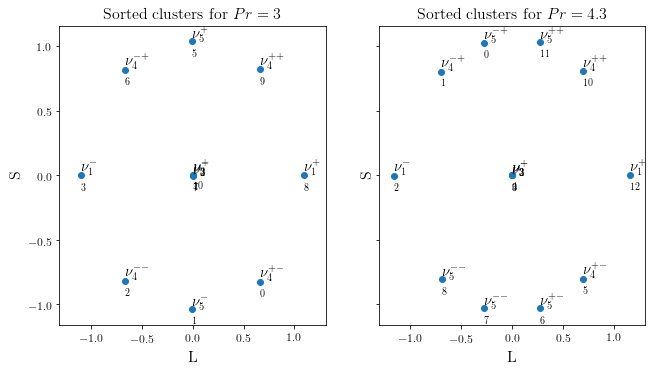

In [11]:
plt.rcParams['figure.figsize'] = (10.5, 5.5)

f, axes = plt.subplots(1, 2, sharey=True, sharex=True)
ax= np.ravel(axes)

ax[0].scatter(kmeans_sym_pr3_ec.cluster_centers_[sorted_pr3[:],0],
              kmeans_sym_pr3_ec.cluster_centers_[sorted_pr3[:],3])

labels = range(n_clusters)

labels_pr3 = ['$\\nu_4^{+-}$','$\\nu_5^{-}$','$\\nu_4^{--}$','$\\nu_1^{-}$','$\\nu_2$','$\\nu_5^{+}$','$\\nu_4^{-+}$', '$\\nu_3^{-}$', '$\\nu_1^{+}$','$\\nu_4^{++}$', '$\\nu_3^{+}$']

for i, txt in enumerate(labels):    
    ax[0].annotate(txt, (kmeans_sym_pr3_ec.cluster_centers_[sorted_pr3[i],0],
                         kmeans_sym_pr3_ec.cluster_centers_[sorted_pr3[i],3]), size=10,xytext=(0,-15), textcoords='offset points')
    
for i, txt in enumerate(labels_pr3):    
    ax[0].annotate(txt, (kmeans_sym_pr3_ec.cluster_centers_[sorted_pr3[i],0],
                         kmeans_sym_pr3_ec.cluster_centers_[sorted_pr3[i],3]),size=15)    

    
ax[1].scatter(kmeans_sym_pr43_ec.cluster_centers_[sorted_pr43[:],0],
              kmeans_sym_pr43_ec.cluster_centers_[sorted_pr43[:],3])

labels_pr43 = ['$\\nu_5^{-+}$','$\\nu_4^{-+}$','$\\nu_1^{-}$','$\\nu_2$','$\\nu_3^{+}$','$\\nu_4^{+-}$','$\\nu_5^{+-}$','$\\nu_5^{--}$','$\\nu_5^{--}$','$\\nu_3^{-}$','$\\nu_4^{++}$','$\\nu_5^{++}$','$\\nu_1^{+}$']

labels = range(n_clusters2)
for i, txt in enumerate(labels):        
    ax[1].annotate(txt, (kmeans_sym_pr43_ec.cluster_centers_[sorted_pr43[i],0],
                         kmeans_sym_pr43_ec.cluster_centers_[sorted_pr43[i],3]),size=10,xytext=(0,-15), textcoords='offset points')


for i, txt in enumerate(labels_pr43):        
    ax[1].annotate(txt, (kmeans_sym_pr43_ec.cluster_centers_[sorted_pr43[i],0],
                         kmeans_sym_pr43_ec.cluster_centers_[sorted_pr43[i],3]),size=15)



ax[0].set_title('Sorted clusters for $Pr=3$', size=16)
ax[0].set_xlabel('$\mathrm{L}$')
ax[0].set_ylabel('$\mathrm{S}$')

ax[1].set_title('Sorted clusters for $Pr=4.3$', size=16)
ax[1].set_xlabel('$\mathrm{L}$')
ax[1].set_ylabel('$\mathrm{S}$')

plt.show()

### 2.3 Flow patterns associated to the cluster centroids (figure 16)

In [14]:
import pickle
filename_pr3 = './data_from_pod/pod_modes_pr3_cr.sav'
cr_pr3  = pickle.load(open(filename_pr3, 'rb'))

def input_matrix(file):   
    import struct
    f = open(file, "rb")
    n = struct.unpack("<f", f.read(4))   
    n = np.array(n[0]).astype(int)    
    y = np.zeros((n,))
    x = np.zeros((n,))
    z = np.zeros((n,n))
    for j in range(n):        
        a = struct.unpack("<f", f.read(4))   
        y[j]=a[0]
        
    for i in range(n):
        a = struct.unpack("<f", f.read(4))   
        x[i]=a[0]
        for j in range(n):        
            a = struct.unpack("<f", f.read(4))   
            z[j,i] = a[0]
            
    return x,y,z ;


dir='data_from_pod/modes_pr43_cr'
x,y,_, = input_matrix(dir+'/field-T-000001.bin')

def streamfunction(U,V,n): 
    Delta=1./np.float(n)
    dpsi = np.zeros((n,n))    
    for i in range(1,n-1):   
        for j in range(1,n-1):   
            dpsi[i,j] = 0.5*(U[i+1,j] + U[i,j] - V[i,j+1] - V[i,j])*Delta
    vpsi = np.zeros((n,n))
    for i in range(1,n): 
        for j in range(1,n):           
            vpsi[i,j] = vpsi[i-1,j-1] + dpsi[i,j]          
    return vpsi;

def reconstruct_pr3(a,mode,n_clusters): 
    df = pd.DataFrame(columns=['T','U','V','Psi'])
    for c in np.arange(0,n_clusters):
        T = a[c,0]*mode.loc['T','k1']
        U = a[c,0]*mode.loc['U','k1']
        V = a[c,0]*mode.loc['V','k1']
        i=1
        for k in ['k2','k4','k3','k5','k6']:
            T = T + a[c,i]*mode.loc['T',k]
            U = U + a[c,i]*mode.loc['U',k]
            V = V + a[c,i]*mode.loc['V',k]
            i=i+1
        Psi = streamfunction(U,V,512)
        
        df = df.append({'T':[T],'U':[U],'V':[V],'Psi':[Psi]}, ignore_index=True) 
        
    return df ;

In [15]:
fields_centroids_pr3 = reconstruct_pr3(kmeans_sym_pr3_ec.cluster_centers_[sorted_pr3[:],:], cr_pr3, n_clusters)

/people/castillo/anaconda3/lib/python3.6/site-packages/matplotlib/figure.py:2267: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


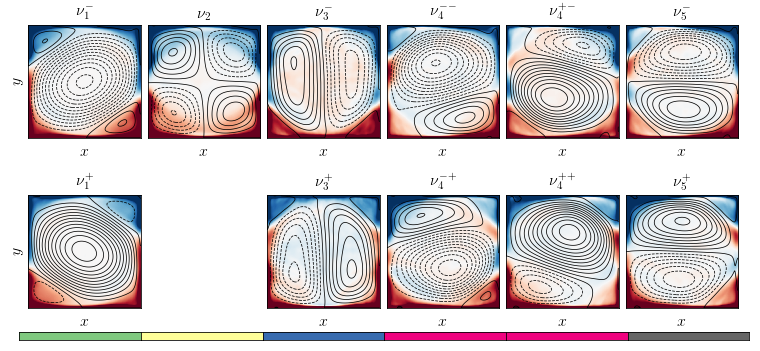

In [16]:
plt.rcParams['figure.figsize'] = (10.5, 4.75)

f, axes = plt.subplots(2,6, sharex=True, sharey=True)
ax= np.ravel(axes)

cmap1 = mpl.cm.RdBu_r
cmap2 = mpl.cm.Accent
norm = mpl.colors.Normalize(vmin=0, vmax=6)

vmin=-0.5; vmax=0.5; i=0
levels=(np.arange(-0.6,0.6,0.04))
for k in [3,4,7,2,0,1, 8,4,10,6,9,5]:
    im=ax[i].imshow(fields_centroids_pr3.loc[k,'T'][0],origin='low', extent=[-0.5, 0.5, -0.5, 0.5], cmap=cmap1, vmin=vmin, vmax=vmax, rasterized=True)
    ax[i].contour(-x,y,fields_centroids_pr3.loc[k,'Psi'][0],levels, colors='k',linewidths=0.75); 
    
    ax[i].set_xlabel('$x$')
    ax[i].set_title(labels_pr3[k],size=16)

    i= i+1
    
ax[0].set_ylabel('$y$')
ax[6].set_ylabel('$y$')
ax[0].set_xlim([-0.5,0.5])
ax[0].set_ylim([-0.5,0.5])
ax[0].set_xticks([])
ax[0].set_yticks([])

cluster_color = [0,2.5,3,4,4,6]
i=0
for axe in ['ax1', 'ax2', 'ax3', 'ax4', 'ax5', 'ax6']:
    axe = f.add_axes([0.03+(0.161)*i, 0.01, 0.161, 0.025])
    axe.set_facecolor(mpl.colors.rgb2hex(cmap2(norm(cluster_color[i]))))
    axe.set_xticks([])
    axe.set_yticks([])
    i=i+1

    
ax[7].set_visible(False)

plt.tight_layout(w_pad=0,h_pad=3.0,rect=[0, 0.03, 1.0, 1.0]) 
plt.savefig('figures_for_article/figure16.pdf',dpi=300)

### 2.4 Sequence of clusters visited over time  (figure 17)

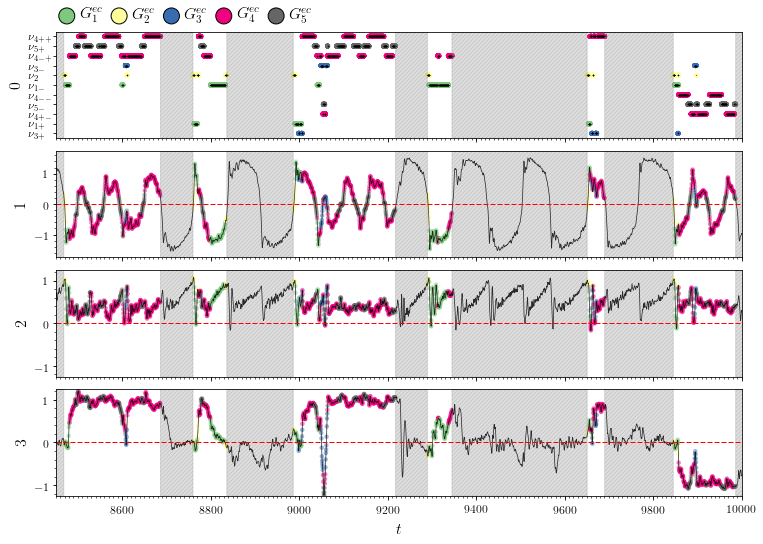

In [17]:
import matplotlib.transforms as mtransforms
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

step = 10
## Cluster name and colors must be matched manually - must redo every time we run k-means
index1=np.array([4,0,4,4,0,4,3,6,6,2.5,3])
index2=np.array(['$c_{4++}^{ec}$','$c_{1-}^{ec}$','$c_{4+-}^{ec}$','$c_{4-+}^{ec}$', '$c_{1+}^{ec}$', '$c_{4--}^{ec}$', '$c_{3-}^{ec}$', '$c_{0-}^{ec}$', '$c_{0+}^{ec}$', '$c_{2}^{ec}$', '$c_{3+}^{ec}$'])
index2=np.array([11             ,               6,              3,              9,              2,               5,              8,             4,              10,            7,                1])

cluster = kmeans_sym_pr3_ec.predict(pod_pr3[['k1','k2','k3','k4','k5','k6']])
pod_pr3['cluster_color']=index1[cluster]
pod_pr3['cluster_number']=index2[cluster]
pod_pr3_ec= pod_pr3.loc[pod_pr3.CRregime==False]

plt.rcParams['figure.figsize'] = (10.5,7.5)

f, axes = plt.subplots(4,1, sharex=True, sharey=False)
ax= np.ravel(axes)

s=20
alpha=0.5
step=10

## Plot the cluster visited at time t
pod_pr3_ec.iloc[::, :].plot(kind='scatter', x='t', y='cluster_number', c='cluster_color', lw = 0.5, legend=False, ax=ax[0], s=20, alpha=1.0, colormap=cmap2, norm=norm, colorbar=False, marker='o', rasterized=True);
pod_pr3_ec.iloc[::, :].plot(kind='scatter', x='t', y='cluster_number', c='k', lw = 0.5, legend=False, ax=ax[0], s=2, alpha=0.5, colormap=cmap2, norm=norm, colorbar=False, marker='.', rasterized=True);

## Plot the amplitudes of modes L, Q, and S
i=1
for k in ['k1','k2','k4']:
    # Plot the time series
    pod_pr3.iloc[::step, :].plot(x='t', y=k,  lw=0.75, c='k', alpha=0.8, legend=False, xlim=[8100,10100], ylim=[-1.25,1.25], ax=ax[i], rasterized=True);
    
    # Color using the clusters
    pod_pr3_ec.head(1000000).iloc[::step, :].plot(kind='scatter', x='t', y=k, c='cluster_color', s=s, lw = 0.0, colormap=cmap2, norm=norm, ax=ax[i], xlim=[8450,10000],colorbar=False, alpha=alpha, rasterized=True);
    
    # Add line for y=0
    ax[i].axhline(y=0,color='red',linewidth=1.0, linestyle='--', dashes=(5, 2), rasterized=True)
    
    # and minor ticks
    majorLocator_y = MultipleLocator(1.0)
    minorLocator_y = MultipleLocator(0.2)
    ax[i].yaxis.set_major_locator(majorLocator_y)
    ax[i].yaxis.set_minor_locator(minorLocator_y)
    i= i+1 
    
    
## Cosmetics
## Shade areas inside the EC subset     
for i in range(0,4):
    trans = mtransforms.blended_transform_factory(ax[i].transData, ax[i].transAxes)
    ax[i].fill_between(pod_pr3.t, 0, 1, where=pod_pr3.CRregime == True, color='gray',facecolor='gray', hatch = '//////', alpha=0.25, transform=trans, rasterized=True)
    ax[i].set_ylabel(labels[i])

    
## Add tics and labels   
ax[1].set_ylim([-1.75,1.75])
majorLocator_x = MultipleLocator(200)
minorLocator_x = MultipleLocator(10)
ax[3].xaxis.set_major_locator(majorLocator_x)
ax[3].xaxis.set_minor_locator(minorLocator_x)
ax[3].set_xlabel('$t$')

## Add caption with coloured circles at the top of the figure
from matplotlib.patches import Circle
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, DrawingArea, HPacker
labels = ['$G_5^{ec}$','$G_1^{ec}$','$G_2^{ec}$','$G_3^{ec}$','$G_4^{ec}$']

box0 = TextArea(labels[0], textprops=dict(size=16, color="k"))
box1 = TextArea(labels[1], textprops=dict(size=16, color="k"))
box2 = TextArea(labels[2], textprops=dict(size=16, color="k"))
box3 = TextArea(labels[3], textprops=dict(size=16, color="k"))
box4 = TextArea(labels[4], textprops=dict(size=16, color="k"))

p0 = Circle((8, 8), 8, ec="k", fc=mpl.colors.rgb2hex(cmap2(norm(6.0))))
p1 = Circle((8, 8), 8, ec="k", fc=mpl.colors.rgb2hex(cmap2(norm(0.0))))
p2 = Circle((8, 8), 8, ec="k", fc=mpl.colors.rgb2hex(cmap2(norm(2.5))))
p3 = Circle((8, 8), 8, ec="k", fc=mpl.colors.rgb2hex(cmap2(norm(3.0))))
p4 = Circle((8, 8), 8, ec="k", fc=mpl.colors.rgb2hex(cmap2(norm(4.0))))

cox0 = DrawingArea(12, 12, 0, 0); cox0.add_artist(p0)
cox1 = DrawingArea(12, 12, 0, 0); cox1.add_artist(p1)
cox2 = DrawingArea(12, 12, 0, 0); cox2.add_artist(p2)
cox3 = DrawingArea(12, 12, 0, 0); cox3.add_artist(p3)
cox4 = DrawingArea(12, 12, 0, 0); cox4.add_artist(p4)

box = HPacker(children=[cox1, box1, cox2, box2, cox3, box3, cox4, box4, cox0, box0],
              align="center",
              pad=3, sep=9)

anchored_box = AnchoredOffsetbox(loc=3,
                                 child=box, pad=0.,
                                 frameon=False,
                                 bbox_to_anchor=(0., 1.02),
                                 bbox_transform=ax[0].transAxes,
                                 borderpad=0.,
                                 )
ax[0].add_artist(anchored_box)

## Add labels for the cluster centroids
ax[0].set_ylim(0.5,11.5)
ax[0].set_yticks(range(1,12))
ax[0].set_yticklabels(['$c_{3+}$','$c_{1+}$','$c_{4+-}$','$c_{5-}$','$c_{4--}$','$c_{1-}$','$c_2$','$c_{3-}$','$c_{4-+}$','$c_{5+}$','$c_{4++}$'])
ax[0].set_yticklabels(['$\\nu_{3+}$','$\\nu_{1+}$','$\\nu_{4+-}$','$\\nu_{5-}$','$\\nu_{4--}$','$\\nu_{1-}$','$\\nu_2$','$\\nu_{3-}$','$\\nu_{4-+}$','$\\nu_{5+}$','$\\nu_{4++}$'])
for label in ax[0].yaxis.get_majorticklabels():
    label.set_horizontalalignment('left')
    label.set_x(-0.03)



plt.tight_layout(pad=0.5) 
plt.savefig('figures_for_article/figure17.pdf',dpi=300)

### 2.5 Sequence of snapshots during a particular cessation

In [18]:
def input_matrix(file):   
    import struct
    f = open(file, "rb")
    n = struct.unpack("<f", f.read(4))   
    n = np.array(n[0]).astype(int)    
    y = np.zeros((n,))
    x = np.zeros((n,))
    z = np.zeros((n,n))
    for j in range(n):        
        a = struct.unpack("<f", f.read(4))   
        y[j]=a[0]
        
    for i in range(n):
        a = struct.unpack("<f", f.read(4))   
        x[i]=a[0]
        for j in range(n):        
            a = struct.unpack("<f", f.read(4))   
            z[j,i] = a[0]
            
    return x,y,z ;

def read_fields(file1, file2, file3):
    x,y,T = input_matrix(file1)
    _,_,U = input_matrix(file2)
    _,_,V = input_matrix(file3)
    return x,y,T,U,V ;

def draw_circle(ax,color):  # circle in the canvas coordinate
    from mpl_toolkits.axes_grid1.anchored_artists import AnchoredDrawingArea
    from matplotlib.patches import Circle
    ada = AnchoredDrawingArea(8, 8, 0, 0,
                              loc=1, borderpad=0.0, frameon=False)
    p = Circle((5, 5), 5, fc=color, ec="w", linewidth=1.5)
    ada.da.add_artist(p)
    ax.add_artist(ada)

9090
9110
9130
9150
9170
9190


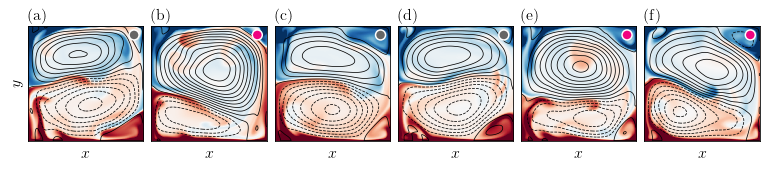

In [20]:
plt.rcParams['figure.figsize'] = (10.5, 2.25)

cmap1 = mpl.cm.RdBu_r

f, axes = plt.subplots(1,6, sharex=True, sharey=True)
ax= np.ravel(axes)

dir='./snapshots_from_dns/RBNT_B2D_RA5e7_PR3_512x512_052'

nsnaps=6
times=np.arange(9090,9300,20)
snaps=(times-9000)/2

times2=np.arange(9882,10000,4)
snaps2=(times2-9750)/2

mode_amplitudes=pod_pr3
levels2=np.arange(-1,1,0.01)
labels=['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)','(j)','(k)','(l)','(m)','(n)']

for i in range(0,nsnaps):
    print(times[i])

    x,y,T,U,V = read_fields(dir+'/field-T-'+'%6.6i' % snaps[i]+'.bin', dir+'/field-U-'+'%6.6i' % snaps[i]+'.bin', dir+'/field-V-'+'%6.6i' % snaps[i]+'.bin')
    Psi = streamfunction(U,V,512);
    im=ax[i].imshow(T-0.5,origin='low', extent=[-0.5, 0.5, -0.5, 0.5], cmap=cmap1, vmin=vmin/2.5, vmax=vmax/2.5)
    ax[i].contour(x,y,Psi,levels2, colors='k',linewidths=0.75);     
    
    mode_amplitudes_current = mode_amplitudes.loc[mode_amplitudes.t==times[i]]
    temp = mode_amplitudes_current['cluster_color'].values   
    color = mpl.colors.rgb2hex(cmap2(norm(temp[0])))
    draw_circle(ax[i],color)
    
    ax[i].set_title(labels[i], fontsize=16, loc='left')

for i in range(0,nsnaps):
    ax[i].set_xlabel('$x$')
    ax[i].set_xlim((-0.5, 0.5))
    ax[i].set_ylim((-0.5, 0.5))
    ax[i].set_xticks([])
    ax[i].set_yticks([])

ax[0].set_ylabel('$y$')


plt.tight_layout(pad=0.0, h_pad=0.0, w_pad=0.1) 
plt.savefig('figures_for_article/figure18a_to_f.pdf',dpi=200)

9882
9886
9890
9894
9898
9902


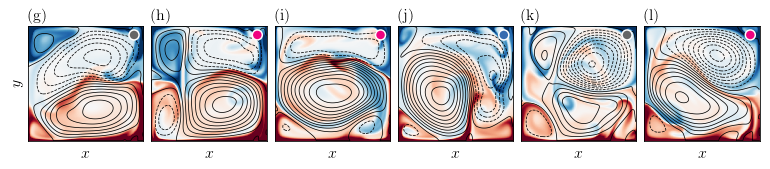

In [23]:
f, axes = plt.subplots(1,6, sharex=True, sharey=True)
ax= np.ravel(axes)

dir='./snapshots_from_dns/RBNT_B2D_RA5e7_PR3_512x512_055'

mode_amplitudes=pod_pr3
levels2=np.arange(-1,1,0.01)
labels=['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)','(j)','(k)','(l)','(m)','(n)']
for i in range(0,nsnaps):
    print(times2[i])

    x,y,T,U,V = read_fields(dir+'/field-T-'+'%6.6i' % snaps2[i]+'.bin', dir+'/field-U-'+'%6.6i' % snaps2[i]+'.bin', dir+'/field-V-'+'%6.6i' % snaps2[i]+'.bin')
    Psi = streamfunction(U,V,512);
    im=ax[i].imshow(T-0.5,origin='low', extent=[-0.5, 0.5, -0.5, 0.5], cmap=cmap1, vmin=vmin/2.5, vmax=vmax/2.5)
    ax[i].contour(x,y,Psi,levels2, colors='k',linewidths=0.75);     
    
    mode_amplitudes_current = mode_amplitudes.loc[mode_amplitudes.t==times2[i]]
    temp = mode_amplitudes_current['cluster_color'].values   
    color = mpl.colors.rgb2hex(cmap2(norm(temp[0])))
    draw_circle(ax[i],color)
    
    ax[i].set_title(labels[i+6], fontsize=16, loc='left')

for i in range(0,nsnaps):
    ax[i].set_xlabel('$x$')
    ax[i].set_xlim((-0.5, 0.5))
    ax[i].set_ylim((-0.5, 0.5))
    ax[i].set_xticks([])
    ax[i].set_yticks([])

ax[0].set_ylabel('$y$')


plt.tight_layout(pad=0.0, h_pad=0.0, w_pad=0.1) 
plt.savefig('figures_for_article/figure18g_to_l.pdf',dpi=200)

### 2.6 Cessation dynamics in the phase-space diagrams  (figure 19), TODO: A2D is pending

In [24]:
step = 10
cluster = kmeans_sym_pr3_ec.predict(alpha_ec_pr3.T)
index=np.array([4,0,4,4,0,4,3,6,6,2.5,3])


Alpha_ec_pr3= pd.DataFrame(alpha_ec_pr3.T, columns=['k1','k2','k3','k4','k5','k6'])
Alpha_ec_pr3['cluster_color'] = index[cluster]

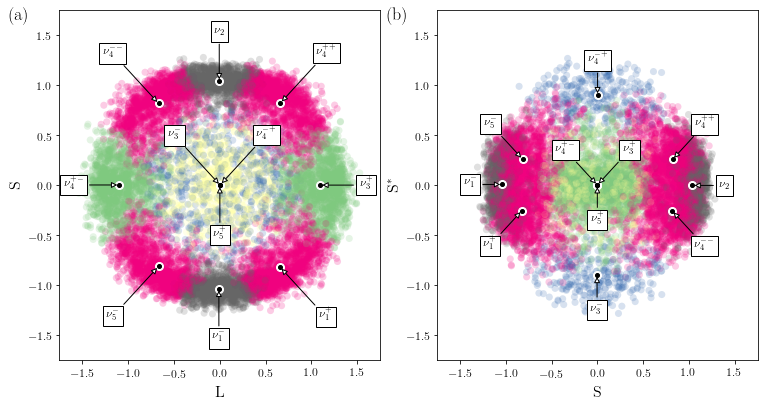

In [25]:
plt.rcParams['figure.figsize'] = (10.5,5.5)

bbox_props = dict(boxstyle="square,pad=0.3", fc="white", ec="k", lw=1)

nsamples=15000
alpha=0.20
s=50


# Colors are selected by hand here
#ax1 = f.add_axes([0.9, 0.7, 0.05, 0.1])
#norm = mpl.colors.Normalize(vmin=0, vmax=6)
#cb1 = mpl.colorbar.ColorbarBase(ax1, cmap=cmap2, norm=norm, orientation='vertical')
#cluster = kmeans_sym_pr3_ec.predict(alpha_ec_pr3.T)
#index=np.array([4,0,4,4,0,4,3,6,6,2.5,3])
#Alpha_ec_pr3= pd.DataFrame(alpha_ec_pr3.T, columns=['k1','k2','k3','k4','k5','k6'])
#Alpha_ec_pr3['cluster_ec'] = index[cluster]

offtagsx = np.zeros((n_clusters,5))
offtagsy = np.zeros((n_clusters,5))

# Offsets for the labels are also set by hand as to improve the visibility 
# For plot in L,Q
#offtagsy[5,0] = 0.5
#offtagsy[0,0] = 0.25 ; offtagsy[10,0] = 0.25
#offtagsy[1:3,0] = -0.5 ; offtagsy[8:10,0] = -0.5
#offtagsy[4,0] = -0.5 ; offtagsy[3,0] = -0.5
#offtagsy[6,0] = 0.75 ; offtagsy[7,0] = 0.75
#offtagsx[0:5,0] = -0.25 ; offtagsx[7:11,0] = 0.25
#offtagsx[1,0] = -0.65 ; offtagsx[2,0] = -0.25
#offtagsx[8,0] = 0.65 ; offtagsx[9,0] = 0.25
#offtagsx[3,0] = 0.25 ; offtagsx[4,0] = -0.25
#offtagsx[6,0] = 0.5 ; offtagsx[7,0] = -0.5

# For plot in L,S
offtagsx[0,0] = -0.5 ; offtagsx[10,0] = 0.5
offtagsy[3,0] = -0.5 ; offtagsy[4,0] = 0.5
offtagsy[1,0] = -0.5 ; offtagsy[2,0] = 0.5 ; offtagsy[6:8,0] = 0.5
offtagsy[8,0] = -0.5 ; offtagsy[9,0] = 0.5 ; offtagsy[5,0] = -0.5
offtagsx[1:3,0] = -0.5 ; offtagsx[8:10,0] = 0.5 ;
offtagsx[6,0] = 0.5 ; offtagsx[7,0] = -0.5

# For plot in L,L*
#offtagsx[0,2] = -0.5 ; offtagsx[10,2] = 0.5
#offtagsx[3,2] = -0.35 ; offtagsx[4,2] = 0.35
#offtagsx[6,2] = 0.35 ; offtagsx[7,2] = -0.35
#offtagsx[1,2] = -0.75 ; offtagsx[2,2] = -0.25
#offtagsx[8,2] = 0.75 ; offtagsx[9,2] = 0.25

#offtagsy[3:5,2] = -0.65 ; offtagsy[6:8,2] = 0.65 ; offtagsy[5,2] = 0.75
#offtagsy[1:3,2] = -0.75 ; offtagsy[8:10,2] = 0.75

# For plot in S,S*
offtagsx[0,1] = -0.35 ; offtagsx[10,1] = 0.35
offtagsx[3,1] = -0.35 ; offtagsx[4,1] = 0.35
offtagsy[0,1] = 0.35 ; offtagsy[10,1] = 0.35 ; offtagsy[5,1] = -0.35

offtagsx[8,1] = -0.35 ; offtagsx[9,1] = 0.35
offtagsx[1,1] = -0.35 ; offtagsx[2,1] = 0.35
offtagsy[6,1] = 0.35 ; offtagsy[7,1] = -0.35
offtagsy[8,1] = -0.35 ; offtagsy[9,1] = 0.35
offtagsy[1,1] = 0.35 ; offtagsy[2,1] = -0.35


f, axes = plt.subplots(1,2, sharex=False, sharey=False)
ax= np.ravel(axes)

i=0
indexx = [0,3,0,3,1]
indexy = [3,5,2,5,4]
coordx = ['k1','k4'] #['k1','k1','k1','k4','k2']
coordy = ['k4','k6','k3','k6','k5']
labelx = ['$\mathrm{L}$','$\mathrm{S}$','$\mathrm{L}$','$\mathrm{S}$','$\mathrm{Q}$']
labely = ['$\mathrm{S}$','$\mathrm{S^*}$','$\mathrm{L}^*$','$\mathrm{S}^*$','$\mathrm{Q}^*$']


labels = range(0,11)
for k in coordx:
    ## Plot the datapoints coloured by cluster 
    Alpha_ec_pr3.sample(nsamples).plot(kind='scatter', x=coordx[i], y=coordy[i], c='cluster_color', s=s, lw = 0.0, colormap=cmap2, norm=norm, ax=ax[i],colorbar=False, alpha=alpha, rasterized=True);

    ## Plot the cluster centroids and the labels
    ax[i].plot(centroids_pr3[:,indexx[i]],centroids_pr3[:,indexy[i]],'ow',markersize=8)
    ax[i].plot(centroids_pr3[:,indexx[i]],centroids_pr3[:,indexy[i]],'ok',markersize=4)
    for j, txt in enumerate(labels_pr3):    
        ax[i].annotate(txt, xy=(centroids_pr3[j,indexx[i]],               centroids_pr3[j,indexy[i]]), size=12, 
                        xytext=(centroids_pr3[j,indexx[i]]+offtagsx[j,i], centroids_pr3[j,indexy[i]]+offtagsy[j,i]), va="center", ha="center", arrowprops=dict(arrowstyle="-|>", facecolor='white'),bbox=bbox_props)
    
    ## Cosmetics    
    ax[i].set_xlabel(labelx[i])
    ax[i].set_ylabel(labely[i])
    ax[i].set_xlabel(labelx[i])
    ax[i].set_ylabel(labely[i])
    ax[i].set_xlim([-1.75,1.75])
    ax[i].set_ylim([-1.75,1.75])
    
    
    i=i+1

#ax[4].set_xlim([-1.0,1.5])
#ax[4].set_ylim([-1.0,1.5])
ax[0].annotate('(a)', xy=(0,1), xycoords='axes fraction', xytext=(-50,-10), textcoords='offset points', fontsize=18)    
ax[1].annotate('(b)', xy=(0,1), xycoords='axes fraction', xytext=(-50,-10), textcoords='offset points', fontsize=18)    


plt.tight_layout(pad=0.1) 
plt.savefig('figures_for_article/figure19.pdf',dpi=300)

### 2.7 Last, we compute the conditional averages for table 5b

In [26]:
glb_pr3['cluster_color']=pod_pr3['cluster_color']

np.seterr(divide='ignore')
conditional_averages = glb_pr3.loc[glb_pr3.CRregime==False].groupby('cluster_color')['f','ekin','apot'].mean()/glb_pr3[['f','ekin','apot']].mean()
pd.set_option('precision', 2)

conditional_averages['prob']=glb_pr3.loc[glb_pr3.CRregime==False].groupby('cluster_color').t.count()/glb_pr3.loc[glb_pr3.CRregime==False].count().t*100
print(conditional_averages[['prob','f','ekin','apot']].to_latex())

\begin{tabular}{lrrrr}
\toprule
{} &   prob &     f &  ekin &  apot \\
cluster\_color &        &       &       &       \\
\midrule
0.0           &  21.89 &  1.03 &  1.02 &  0.97 \\
2.5           &   5.76 &  0.28 &  0.75 &  1.06 \\
3.0           &   4.61 &  0.32 &  1.04 &  0.84 \\
4.0           &  49.04 &  0.58 &  0.89 &  1.02 \\
6.0           &  18.71 &  0.18 &  0.78 &  1.14 \\
\bottomrule
\end{tabular}

